In [1]:
# from numba import cuda
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx


pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output', 
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([1e3, 1e3, 1e3], dtype=float)

# m_filter = 1000*snap.mass
# filter_length = (np.cbrt(3*m_filter/(4*np.pi*snap['0_Density']))).arepo
filter_length = 2.0*snap['0_Diameters']
weight='0_Volume'
filter_type = 'gaussian'





The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)


Attempting to get derived variable: 0_Diameters...
	So we need the variable: 0_Volume...	[DONE]



In [2]:
import cmasher as cmr
%matplotlib widget
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

widths_slicer = widths.copy()
widths_slicer[2] = 0.
slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=2048)
extent = slicer.centered_extent.to('Mpc')

In [3]:
def extract_turbulent_scalar(snap, sf, variable, filter_length, weight, filter_type):
    
    filt_var = sf.filter_variable(variable, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True)

    print("min/max/avg occupancy cartesian tiling %d / %d / %.2f"%(sf.tile.particles_per_tile.min(),
                                                                    sf.tile.particles_per_tile.max(),
                                                                    cp.mean(sf.tile.particles_per_tile)))
    
    smoothVar = snap[variable].copy
    smoothVar[sf.index] = filt_var
    
    turbVar = np.zeros_like(snap[variable])
    turbVar[sf.index] = snap[variable][sf.index] - filt_var

    return smoothVar, turbVar


def extract_turbulent_energy(snap, sf, vector_variable, filter_length, weight, filter_type):
    variable_x = snap[vector_variable][:,0]
    variable_y = snap[vector_variable][:,1]
    variable_z = snap[vector_variable][:,2]
    
    filt_var_x = sf.filter_variable(variable_x, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True)
    filt_var_y = sf.filter_variable(variable_y, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True)
    filt_var_z = sf.filter_variable(variable_z, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True)

    print("min/max/avg occupancy cartesian tiling %d / %d / %.2f"%(sf.tile.particles_per_tile.min(),
                                                                    sf.tile.particles_per_tile.max(),
                                                                    cp.mean(sf.tile.particles_per_tile)))

    final_filter_length = 0.0*filter_length.copy
    final_filter_length[sf.index] = sf.filter_lengths_out.get()*filter_length.unit

    smoothEner = np.zeros_like(snap[vector_variable][:,0]**2)
    smoothEner[sf.index] = 0.5*(filt_var_x**2 + filt_var_y**2 + filt_var_z**2)
    
    delta_var_x = variable_x[sf.index] - filt_var_x
    delta_var_y = variable_y[sf.index] - filt_var_y
    delta_var_z = variable_z[sf.index] - filt_var_z

    turbEner = np.zeros_like(snap[vector_variable][:,0]**2)
    turbEner[sf.index] = 0.5*(delta_var_x**2 + delta_var_y**2 + delta_var_z**2)
    turbVec = np.stack((delta_var_x,delta_var_y,delta_var_z),axis=1)

    return smoothEner, turbEner, turbVec, final_filter_length

def extract_turbulent_energy_vector(snap, sf, vector_variable, filter_length, weight, filter_type, norm):
    variable_x = snap[vector_variable][:,0]
    variable_y = snap[vector_variable][:,1]
    variable_z = snap[vector_variable][:,2]
    
    filt_var_x, filt_var_y, filt_var_z  = sf.filter_vector(variable_x, variable_y, variable_z, filter_length, weight=weight, 
                                      filter_type=filter_type, iterative=True, optimized=True, norm=norm)
     

    print("min/max/avg occupancy cartesian tiling %d / %d / %.2f"%(sf.tile.particles_per_tile.min(),
                                                                    sf.tile.particles_per_tile.max(),
                                                                    cp.mean(sf.tile.particles_per_tile)))

    final_filter_length = 0.0*filter_length.copy
    final_filter_length[sf.index] = sf.filter_lengths_out.get()*filter_length.unit

    smoothEner = np.zeros_like(snap[vector_variable][:,0]**2)
    smoothEner[sf.index] = 0.5*(filt_var_x**2 + filt_var_y**2 + filt_var_z**2)
    
    delta_var_x = variable_x[sf.index] - filt_var_x
    delta_var_y = variable_y[sf.index] - filt_var_y
    delta_var_z = variable_z[sf.index] - filt_var_z

    turbEner = np.zeros_like(snap[vector_variable][:,0]**2)
    turbEner[sf.index] = 0.5*(delta_var_x**2 + delta_var_y**2 + delta_var_z**2)
    turbVec = np.stack((delta_var_x,delta_var_y,delta_var_z),axis=1)

    return smoothEner, turbEner, turbVec, final_filter_length

In [4]:
snap['0_DensitySqrt'] = np.sqrt(snap['0_Density'])
sqrtrhovx = snap['0_DensitySqrt']*snap['0_Velocities'][:,0]
sqrtrhovy = snap['0_DensitySqrt']*snap['0_Velocities'][:,1]
sqrtrhovz = snap['0_DensitySqrt']*snap['0_Velocities'][:,2]
sqrtrhov = np.stack((sqrtrhovx,sqrtrhovy,sqrtrhovz),axis=1)
snap['0_DensitySqrtVelocities'] = sqrtrhov
snap['0_DensitySqrtVelocitiesNorm'] = np.sqrt(sqrtrhovx**2 + sqrtrhovy**2 + sqrtrhovz**2)

In [5]:
# when using the iterative filter we need to make sure that the particles required are
# loaded on the GPU. This can be achieved by increasing the search_radius
# to be larger than the maximum filter_radius of the iterative loop
sf = tc.SmoothingFilter(snap, center, widths, npix=128, orientation=None, 
                        search_radius=10.*filter_length.value)

In [6]:
VEC_smoothEner, VEC_turbEner, VEC_turbVec, VEC_filter_length_vel = extract_turbulent_energy(snap, sf, 
                                            '0_DensitySqrtVelocities', filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type)


99.71 percent of particles (10846971 / 10878468) has converged
99.76 percent of particles (10851898 / 10878468) has converged
99.72 percent of particles (10848096 / 10878468) has converged
min/max/avg occupancy cartesian tiling 0 / 381 / 8.96


In [7]:
@cuda.jit(device=True, inline=True)
def distance(pos, pos_other):
    dist = math.sqrt((pos[0] - pos_other[0])**2 +
                     (pos[1] - pos_other[1])**2 +
                     (pos[2] - pos_other[2])**2)
    return dist


@cuda.jit(device=True, inline=True)
def gaussian_kernel(dist, filter_length):

    weight = math.exp(-0.5*(dist/filter_length)**2)

    return weight

@cuda.jit(device=True, inline=True)
def check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                   tile_x, tile_y, tile_z,
                   delta_x, delta_y, delta_z,
                   tile_widths, filter_length):

    overlap = False

    xcoord_edge = delta_x
    if (tile_x > ip_tile_x):
        xcoord_edge = tile_widths[0] * (tile_x - ip_tile_x - 0.5)
    elif (tile_x < ip_tile_x):
        xcoord_edge = tile_widths[0] * (tile_x - ip_tile_x + 0.5)

    ycoord_edge = delta_y
    if (tile_y > ip_tile_y):
        ycoord_edge = tile_widths[1] * (tile_y - ip_tile_y - 0.5)
    elif (tile_y < ip_tile_y):
        ycoord_edge = tile_widths[1] * (tile_y - ip_tile_y + 0.5)

    zcoord_edge = delta_z
    if (tile_z > ip_tile_z):
        zcoord_edge = tile_widths[2] * (tile_z - ip_tile_z - 0.5)
    elif (tile_z < ip_tile_z):
        zcoord_edge = tile_widths[2] * (tile_z - ip_tile_z + 0.5)
        
    dist2 = (delta_x - xcoord_edge)**2 + \
            (delta_y - ycoord_edge)**2 + \
            (delta_z - zcoord_edge)**2

    filt2 = filter_length**2
    if (filt2 >= dist2):
        overlap = True
    
    return overlap



@cuda.jit()
def check_particle(pos, hsml, center, widths, isParticleInDomain):
    """
    """
    ip = cuda.grid(1)
    # each thread is assigned to a particle
    numParticles = pos.shape[0]
    isParticleInDomainTmp = 0

    if (ip < numParticles):

        xp, yp, zp = pos[ip]
        xmin = center[0] - widths[0] / 2 - hsml[ip]
        xmax = center[0] + widths[0] / 2 + hsml[ip]

        ymin = center[1] - widths[1] / 2 - hsml[ip]
        ymax = center[1] + widths[1] / 2 + hsml[ip]

        zmin = center[2] - widths[2] / 2 - hsml[ip]
        zmax = center[2] + widths[2] / 2 + hsml[ip]

        if (xp > xmin) and (xp < xmax):
            if (yp > ymin) and (yp < ymax):
                if (zp > zmin) and (zp < zmax):
                    isParticleInDomainTmp = 1


        isParticleInDomain[ip] = isParticleInDomainTmp

@cuda.jit()
def compactify_particles(pos, tile_index, cumulative_occupancy_flat, isParticleInDomain,
                         oldIndex):
    """
    """
    ip = cuda.grid(1)
    numParticles = pos.shape[0]
    # each thread takes care of a particle
    if (ip < numParticles):
        newPos = int(cumulative_occupancy_flat[ip])
        if (isParticleInDomain[ip] > 0):
            oldIndex[newPos - 1] = ip


@cuda.jit()
def apply_filter_optimized_vector1(oldIndex, pos, hsml, tile_index, 
                     start_index_for_tile, particles_per_tile, tile_widths,
                     variable_x, variable_y, variable_z, weights, offsets, npixs, center, widths, filter_lengths, 
                     smooth_var_x, smooth_var_y, smooth_var_z, filter_type, hitsNeighbours, isParticleInDomain, 
                     iterativeFilter, hasConverged, numIterations, filter_lengths_out):
    """
    filter_lengths is an array of size pos.shape([0])
    type can be "mean" or "gaussian"
    """
    # threadindex
    ip = cuda.grid(1)

    if (ip < oldIndex.shape[0]):
        oldIp = oldIndex[ip]
    
        # particle position
        xp = pos[oldIp, 0]
        yp = pos[oldIp, 1]
        zp = pos[oldIp, 2]

        oldVarRegister_x = variable_x[oldIp]
        oldVarRegister_y = variable_y[oldIp]
        oldVarRegister_z = variable_z[oldIp]

        if (iterativeFilter == 0): # no iterative
            filter_length = filter_lengths[oldIp]
        else: #iterative
            # iterative scheme ~Vazza+2012 
            # filter length is gradually increased
            filter_length = 0.1 * filter_lengths[oldIp] 
            if (0.1 * filter_lengths[oldIp] < 1.0 * hsml[oldIp]):  
                filter_length = 1.0 * hsml[oldIp] 
            # let's start from 10% of the filter_length or 1 x hsml, whichever is largest
            
        filterIncrease = 0.5*hsml[oldIp] # it is additive factor (?)
        max_filter_length = 20.0*filter_lengths[oldIp] 
        # need to make sure that with max_filter_length it does not go
        # beyond region loaded on GPU
        
        hasIterationConverged = False
    
        turbFieldOld_x, turbFieldOld_y, turbFieldOld_z = 0.0, 0.0, 0.0
        turbFieldNew_x, turbFieldNew_y, turbFieldNew_z = 0.0, 0.0, 0.0
        toleranceParam = 0.05
    
        numInteractingPartOld = 0
        numInteractingPartNew = 0
        

        ip_tile_x = tile_index[oldIp, 0]
        ip_tile_y = tile_index[oldIp, 1]
        ip_tile_z = tile_index[oldIp, 2]
    
        # relative coordinates w.r.t. center of tile
        delta_x = xp - offsets[0] - (ip_tile_x + 0.5) * tile_widths[0] 
        delta_y = yp - offsets[1] - (ip_tile_y + 0.5) * tile_widths[1] 
        delta_z = zp - offsets[2] - (ip_tile_z + 0.5) * tile_widths[2] 
    
        filter_window = 1
        # for gaussian filter the sigma is  1/4 of the
        # filter_length of the source particle
        if filter_type == 1:
            filter_window = 4

        numIter = 0
        while (filter_length <= max_filter_length and not hasIterationConverged):
            # the idea is to use this while loop both for iterative and non-iterative case
            # if non-iterative we exit after one go
            
            smoothVarRegister_x, smoothVarRegister_y, smoothVarRegister_z = 0.0, 0.0, 0.0
            weight = 0.0
            weight_tmp = 0.0
            numInteractingPartNew = 0

            ####################################
            # code to check what are the tiles that can overlap
            # with the particle filter_length
            ####################################

            
            ip_tile_x_min = ip_tile_x - (- delta_x + \
                            filter_length + tile_widths[0] / 2) // tile_widths[0] 
            ip_tile_x_max = ip_tile_x + (delta_x +   \
                            filter_length + tile_widths[0] / 2) // tile_widths[0] 
        
            ip_tile_y_min = ip_tile_y - (- delta_y + \
                            filter_length + tile_widths[1] / 2) // tile_widths[1] 
            ip_tile_y_max = ip_tile_y + (delta_y +   \
                            filter_length + tile_widths[1] / 2) // tile_widths[1] 
        
            ip_tile_z_min = ip_tile_z - (- delta_z + \
                            filter_length + tile_widths[2] / 2) // tile_widths[2] 
            ip_tile_z_max = ip_tile_z + (delta_z +   \
                            filter_length + tile_widths[2] / 2) // tile_widths[2] 

            ####################################
            # end of code to check overlap
            ####################################
            
            if filter_type == 0:
                for tile_x in range(ip_tile_x_min, ip_tile_x_max + 1):
                    for tile_y in range(ip_tile_y_min, ip_tile_y_max + 1):
                        for tile_z in range(ip_tile_z_min, ip_tile_z_max + 1):
                            if check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                                              tile_x, tile_y, tile_z,
                                              delta_x, delta_y, delta_z,
                                              tile_widths, filter_length):
    
                                start_index = start_index_for_tile[tile_x,
                                                                   tile_y, tile_z]
                                n_particles = particles_per_tile[tile_x,
                                                                 tile_y, tile_z]
            
                                for ip_other in range(start_index, start_index + n_particles):
                                    dist = distance((xp, yp, zp), pos[ip_other])
                                    if dist < filter_length:
                                        weight_tmp = 1.0 * weights[ip_other]
                                        weight += weight_tmp
                                        smoothVarRegister_x += variable_x[ip_other] * weight_tmp
                                        smoothVarRegister_y += variable_y[ip_other] * weight_tmp
                                        smoothVarRegister_z += variable_z[ip_other] * weight_tmp
                                        numInteractingPartNew += 1
        
            elif filter_type == 1:
                for tile_x in range(ip_tile_x_min, ip_tile_x_max + 1):
                    for tile_y in range(ip_tile_y_min, ip_tile_y_max + 1):
                        for tile_z in range(ip_tile_z_min, ip_tile_z_max + 1):
                            if check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                                              tile_x, tile_y, tile_z,
                                              delta_x, delta_y, delta_z,
                                              tile_widths, filter_length):
                                start_index = start_index_for_tile[tile_x,
                                                                   tile_y, tile_z]
                                n_particles = particles_per_tile[tile_x,
                                                                 tile_y, tile_z]
            
                                for ip_other in range(start_index, start_index + n_particles):
                                    dist = distance((xp, yp, zp), pos[ip_other])
                                    if dist < filter_length:
                                        weight_tmp = gaussian_kernel(dist, filter_length / filter_window) * weights[ip_other]
                                        weight += weight_tmp
                                        smoothVarRegister_x += variable_x[ip_other] * weight_tmp
                                        smoothVarRegister_y += variable_y[ip_other] * weight_tmp
                                        smoothVarRegister_z += variable_z[ip_other] * weight_tmp
                                        numInteractingPartNew += 1
            
            if weight > 0.:
                smoothVarRegister_x /= weight
                smoothVarRegister_y /= weight
                smoothVarRegister_z /= weight

            ################################
            # part to check convergence of iterative filter
            ################################
            
            if (iterativeFilter == 0): # no iterative
                hasIterationConverged = True
            else: # iterative
                turbFieldNew_x = oldVarRegister_x - smoothVarRegister_x
                turbFieldNew_y = oldVarRegister_y - smoothVarRegister_y
                turbFieldNew_z = oldVarRegister_z - smoothVarRegister_z

                # here we can decide on what to base the convergence
                # criterion: e.g., the norm of the fluctuation vector, or the square, etc...
                # here is the L1-norm
                norm_Old = abs(turbFieldOld_x) + abs(turbFieldOld_y) + abs(turbFieldOld_z)
                relIncrease =  (abs(turbFieldNew_x - turbFieldOld_x) + abs(turbFieldNew_y - turbFieldOld_y) + \
                                abs(turbFieldNew_z - turbFieldOld_z) ) / norm_Old
                # we declare the iteration converged when all the following are satisfied:
                # 1. the relative increase is less than the tolerance
                # 2. we have done at least one iteration (so we can compare old and new)
                # 3. the number of particles at the new iteration has increased
                # (if the number did not increase this would naturally cause 1. to be true)
                if (relIncrease <= toleranceParam and numIter > 0 and numInteractingPartNew > numInteractingPartOld):
                    hasIterationConverged = True
                    hasConverged[oldIp] = 1
                else: # not converged
                    filter_length += filterIncrease
                    turbFieldOld_x = turbFieldNew_x
                    turbFieldOld_y = turbFieldNew_y
                    turbFieldOld_z = turbFieldNew_z
                    numIter += 1
                    numInteractingPartOld = numInteractingPartNew

            ################################
            # end of check convergence of iterative filter
            ################################

        smooth_var_x[oldIp] = smoothVarRegister_x
        smooth_var_y[oldIp] = smoothVarRegister_y
        smooth_var_z[oldIp] = smoothVarRegister_z
        
        hitsNeighbours[oldIp] = numInteractingPartNew
        if (iterativeFilter == 1): # iterative
            filter_lengths_out[oldIp] = filter_length
            numIterations[oldIp] = numIter
            if not hasIterationConverged:
                # this is to adjust for the last iteration
                filter_lengths_out[oldIp] -= filterIncrease
                numIterations[oldIp] -= 1
                


In [8]:
@cuda.jit()
def apply_filter_optimized_vector2(oldIndex, pos, hsml, tile_index, 
                     start_index_for_tile, particles_per_tile, tile_widths,
                     variable_x, variable_y, variable_z, weights, offsets, npixs, center, widths, filter_lengths, 
                     smooth_var_x, smooth_var_y, smooth_var_z, filter_type, hitsNeighbours, isParticleInDomain, 
                     iterativeFilter, hasConverged, numIterations, filter_lengths_out):
    """
    filter_lengths is an array of size pos.shape([0])
    type can be "mean" or "gaussian"
    """
    # threadindex
    ip = cuda.grid(1)

    if (ip < oldIndex.shape[0]):
        oldIp = oldIndex[ip]
    
        # particle position
        xp = pos[oldIp, 0]
        yp = pos[oldIp, 1]
        zp = pos[oldIp, 2]

        oldVarRegister_x = variable_x[oldIp]
        oldVarRegister_y = variable_y[oldIp]
        oldVarRegister_z = variable_z[oldIp]

        if (iterativeFilter == 0): # no iterative
            filter_length = filter_lengths[oldIp]
        else: #iterative
            # iterative scheme ~Vazza+2012 
            # filter length is gradually increased
            filter_length = 0.1 * filter_lengths[oldIp] 
            if (0.1 * filter_lengths[oldIp] < 1.0 * hsml[oldIp]):  
                filter_length = 1.0 * hsml[oldIp] 
            # let's start from 10% of the filter_length or 1 x hsml, whichever is largest
            
        filterIncrease = 0.5*hsml[oldIp] # it is additive factor (?)
        max_filter_length = 20.0*filter_lengths[oldIp] 
        # need to make sure that with max_filter_length it does not go
        # beyond region loaded on GPU
        
        hasIterationConverged = False
    
        turbFieldOld_x, turbFieldOld_y, turbFieldOld_z = 0.0, 0.0, 0.0
        turbFieldNew_x, turbFieldNew_y, turbFieldNew_z = 0.0, 0.0, 0.0
        toleranceParam = 0.05
    
        numInteractingPartOld = 0
        numInteractingPartNew = 0
        

        ip_tile_x = tile_index[oldIp, 0]
        ip_tile_y = tile_index[oldIp, 1]
        ip_tile_z = tile_index[oldIp, 2]
    
        # relative coordinates w.r.t. center of tile
        delta_x = xp - offsets[0] - (ip_tile_x + 0.5) * tile_widths[0] 
        delta_y = yp - offsets[1] - (ip_tile_y + 0.5) * tile_widths[1] 
        delta_z = zp - offsets[2] - (ip_tile_z + 0.5) * tile_widths[2] 
    
        filter_window = 1
        # for gaussian filter the sigma is  1/4 of the
        # filter_length of the source particle
        if filter_type == 1:
            filter_window = 4

        numIter = 0
        while (filter_length <= max_filter_length and not hasIterationConverged):
            # the idea is to use this while loop both for iterative and non-iterative case
            # if non-iterative we exit after one go
            
            smoothVarRegister_x, smoothVarRegister_y, smoothVarRegister_z = 0.0, 0.0, 0.0
            weight = 0.0
            weight_tmp = 0.0
            numInteractingPartNew = 0

            ####################################
            # code to check what are the tiles that can overlap
            # with the particle filter_length
            ####################################

            
            ip_tile_x_min = ip_tile_x - (- delta_x + \
                            filter_length + tile_widths[0] / 2) // tile_widths[0] 
            ip_tile_x_max = ip_tile_x + (delta_x +   \
                            filter_length + tile_widths[0] / 2) // tile_widths[0] 
        
            ip_tile_y_min = ip_tile_y - (- delta_y + \
                            filter_length + tile_widths[1] / 2) // tile_widths[1] 
            ip_tile_y_max = ip_tile_y + (delta_y +   \
                            filter_length + tile_widths[1] / 2) // tile_widths[1] 
        
            ip_tile_z_min = ip_tile_z - (- delta_z + \
                            filter_length + tile_widths[2] / 2) // tile_widths[2] 
            ip_tile_z_max = ip_tile_z + (delta_z +   \
                            filter_length + tile_widths[2] / 2) // tile_widths[2] 

            ####################################
            # end of code to check overlap
            ####################################
            
            if filter_type == 0:
                for tile_x in range(ip_tile_x_min, ip_tile_x_max + 1):
                    for tile_y in range(ip_tile_y_min, ip_tile_y_max + 1):
                        for tile_z in range(ip_tile_z_min, ip_tile_z_max + 1):
                            if check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                                              tile_x, tile_y, tile_z,
                                              delta_x, delta_y, delta_z,
                                              tile_widths, filter_length):
    
                                start_index = start_index_for_tile[tile_x,
                                                                   tile_y, tile_z]
                                n_particles = particles_per_tile[tile_x,
                                                                 tile_y, tile_z]
            
                                for ip_other in range(start_index, start_index + n_particles):
                                    dist = distance((xp, yp, zp), pos[ip_other])
                                    if dist < filter_length:
                                        weight_tmp = 1.0 * weights[ip_other]
                                        weight += weight_tmp
                                        smoothVarRegister_x += variable_x[ip_other] * weight_tmp
                                        smoothVarRegister_y += variable_y[ip_other] * weight_tmp
                                        smoothVarRegister_z += variable_z[ip_other] * weight_tmp
                                        numInteractingPartNew += 1
        
            elif filter_type == 1:
                for tile_x in range(ip_tile_x_min, ip_tile_x_max + 1):
                    for tile_y in range(ip_tile_y_min, ip_tile_y_max + 1):
                        for tile_z in range(ip_tile_z_min, ip_tile_z_max + 1):
                            if check_distance(ip_tile_x, ip_tile_y, ip_tile_z,
                                              tile_x, tile_y, tile_z,
                                              delta_x, delta_y, delta_z,
                                              tile_widths, filter_length):
                                start_index = start_index_for_tile[tile_x,
                                                                   tile_y, tile_z]
                                n_particles = particles_per_tile[tile_x,
                                                                 tile_y, tile_z]
            
                                for ip_other in range(start_index, start_index + n_particles):
                                    dist = distance((xp, yp, zp), pos[ip_other])
                                    if dist < filter_length:
                                        weight_tmp = gaussian_kernel(dist, filter_length / filter_window) * weights[ip_other]
                                        weight += weight_tmp
                                        smoothVarRegister_x += variable_x[ip_other] * weight_tmp
                                        smoothVarRegister_y += variable_y[ip_other] * weight_tmp
                                        smoothVarRegister_z += variable_z[ip_other] * weight_tmp
                                        numInteractingPartNew += 1
            
            if weight > 0.:
                smoothVarRegister_x /= weight
                smoothVarRegister_y /= weight
                smoothVarRegister_z /= weight

            ################################
            # part to check convergence of iterative filter
            ################################
            
            if (iterativeFilter == 0): # no iterative
                hasIterationConverged = True
            else: # iterative
                turbFieldNew_x = oldVarRegister_x - smoothVarRegister_x
                turbFieldNew_y = oldVarRegister_y - smoothVarRegister_y
                turbFieldNew_z = oldVarRegister_z - smoothVarRegister_z

                # here we can decide on what to base the convergence
                # criterion: e.g., the norm of the fluctuation vector, or the square, etc...
                # this is the L2 norm convergence
                norm_Old = math.sqrt(turbFieldOld_x**2 + turbFieldOld_y**2 + turbFieldOld_z**2)
                relIncrease =  math.sqrt((turbFieldNew_x - turbFieldOld_x)**2 + (turbFieldNew_y - turbFieldOld_y)**2 + \
                                (turbFieldNew_z - turbFieldOld_z)**2 ) / norm_Old
                # we declare the iteration converged when all the following are satisfied:
                # 1. the relative increase is less than the tolerance
                # 2. we have done at least one iteration (so we can compare old and new)
                # 3. the number of particles at the new iteration has increased
                # (if the number did not increase this would naturally cause 1. to be true)
                if (relIncrease <= toleranceParam and numIter > 0 and numInteractingPartNew > numInteractingPartOld):
                    hasIterationConverged = True
                    hasConverged[oldIp] = 1
                else: # not converged
                    filter_length += filterIncrease
                    turbFieldOld_x = turbFieldNew_x
                    turbFieldOld_y = turbFieldNew_y
                    turbFieldOld_z = turbFieldNew_z
                    numIter += 1
                    numInteractingPartOld = numInteractingPartNew

            ################################
            # end of check convergence of iterative filter
            ################################

        smooth_var_x[oldIp] = smoothVarRegister_x
        smooth_var_y[oldIp] = smoothVarRegister_y
        smooth_var_z[oldIp] = smoothVarRegister_z
        
        hitsNeighbours[oldIp] = numInteractingPartNew
        if (iterativeFilter == 1): # iterative
            filter_lengths_out[oldIp] = filter_length
            numIterations[oldIp] = numIter
            if not hasIterationConverged:
                # this is to adjust for the last iteration
                filter_lengths_out[oldIp] -= filterIncrease
                numIterations[oldIp] -= 1
                


In [9]:
class Lorenzo(tc.SmoothingFilter):
    def filter_vector(self, variable_x, variable_y, variable_z, filter_length, weight=None, 
                       filter_type="mean", iterative=False,
                       shared_mem=False, Nmax=64, optimized=False, norm=1):
        """
        shared_mem has been tested only with filter_type="mean"
        Nmax is the max number of particles per block. Each tile is split
        in "logic" blocks with Nmax particles max (can be less, but not zero)
        and assigned to exactly 1 block of threads with Nmax threads
        """

        if (shared_mem and optimized):
            raise RuntimeError('shared_mem and optimized are incompatible')
        if (shared_mem and iterative):
            raise RuntimeError('shared_mem and iterative are incompatible')
            
        rng0 = nvtx.start_range(message="do_filter")
        
        variable_x_str, unit_quantity = self._send_variable_to_gpu(variable_x, gpu_key='input_variable_x')
        variable_y_str, unit_quantity = self._send_variable_to_gpu(variable_y, gpu_key='input_variable_y')
        variable_z_str, unit_quantity = self._send_variable_to_gpu(variable_z, gpu_key='input_variable_z')

        if weight is not None:
            if isinstance(weight, str):
                self._send_variable_to_gpu(weight)
            else:
                raise RuntimeError('has to be a string')

        # send filter_length to gpu
        if isinstance(filter_length, np.ndarray):
            assert filter_length.shape[0] == self.index.shape[0]
            if (np.max(filter_length[self.indicesFirstPass]) > self.max_search_radius):
                raise RuntimeError('The chosen filter length is larger than the \
                maximum search radius. This would cause searching for cells that \
                have not been moved to the GPU. To solve this decrease \
                the filter length or increase the search radius accordingly')
            self._send_variable_to_gpu(filter_length, gpu_key='filter_lengths')
        else:
            if (filter_length > self.max_search_radius):
                raise RuntimeError('The chosen filter length is larger than the \
                maximum search radius. This would cause searching for cells that \
                have not been moved to the GPU. To solve this decrease \
                the filter length or increase the search radius accordingly')
            self.gpu_variables['filter_lengths'] = cp.ones(self.Np) * filter_length

        # Do the filtering
        if not shared_mem:
            if optimized:
                if (norm == 1):
                    smooth_variable_x, smooth_variable_y, smooth_variable_z  = self._apply_filter_gpu_optimized_vector1(
                                                                variable_x_str, variable_y_str,
                                                               variable_z_str, weight, 
                                                               filter_type, iterative)
                elif (norm == 2):
                    smooth_variable_x, smooth_variable_y, smooth_variable_z  = self._apply_filter_gpu_optimized_vector2(
                                                                variable_x_str, variable_y_str,
                                                               variable_z_str, weight, 
                                                               filter_type, iterative)
        #     else: 
        #         smooth_variable = self._apply_filter_gpu(variable_str, weight, filter_type, iterative)
        # else:
        #     smooth_variable = self._apply_filter_gpu_shared(variable_str, weight, filter_type, Nmax)

        if unit_quantity is not None:
            smooth_variable_x = smooth_variable_x * unit_quantity
            smooth_variable_y = smooth_variable_y * unit_quantity
            smooth_variable_z = smooth_variable_z * unit_quantity

        nvtx.end_range(rng0)
        
        return smooth_variable_x, smooth_variable_y, smooth_variable_z

    def _apply_filter_gpu_optimized_vector1(self, variable_x_str, variable_y_str, variable_z_str, weight, filter_type, iterative):
        """
        The idea behind this 'optimized' version is to check if the particle
        is in the domain _beforehand_, and then run the filtering kernel 
        only on those that are in the domain. There is a certain speedup 
        in doing so (for small-size problems running time can be 1/3)
        I have also improved the tile searching within the kernel: now only
        the tiles that *overlap* with the filtering radius of each particle
        are selected, without wasting time looping over those that do not
        For now I am adding it as an option to the filter_variable function
        (optimized=True) to allow a comparison with the baseline 
        (optimized=False)
        """

        if self.spherical:
            raise RuntimeError('optimized filter has only \
                                been tested with cartesian grids')
            
        pos = self.gpu_variables['pos']
        hsml = self.gpu_variables['hsml']
        # - self.tile.off_sets[None,:]
        tile_index = self.tile.tile_index
        start_index_for_tile = self.tile.start_index_for_tile
        particles_per_tile = self.tile.particles_per_tile
        tile_widths = self.tile.tile_widths
        
        variable_x = self.gpu_variables[variable_x_str]
        variable_y = self.gpu_variables[variable_y_str]
        variable_z = self.gpu_variables[variable_z_str]
        
        npixs = self.tile.npixs
        center = self.gpu_variables['center']
        widths = self.gpu_variables['widths']
        offsets = self.tile.off_sets
        filter_lengths = self.gpu_variables['filter_lengths']
        if filter_type == "mean":
            filter_type = 0
        elif filter_type == "gaussian":
            filter_type = 1

        iterativeFilter = 0 # not iterative
        if iterative:
            iterativeFilter = 1 # iterative
        

        if cp.max(filter_lengths) > self.extra_layer_thickness_value:
            err_msg = f"{cp.max(filter_lengths)} is larger than {self.extra_layer_thickness}"
            raise RuntimeError(err_msg)

        if weight is not None:
            weights = self.gpu_variables[weight]
        else:
            weights = cp.ones_like(variable_x)

        isParticleInDomain = cp.zeros(pos.shape[0])
        
        check_particle[self.blocks_1d, self.threadsperblock](pos, hsml, center, widths, isParticleInDomain)
        self.isParticleInDomain = isParticleInDomain
        cumulative_occupancy = cp.cumsum(isParticleInDomain)
        numParticlesInDomain = int(cumulative_occupancy[-1])
        oldIndex = cp.zeros(numParticlesInDomain,dtype=int)
        
        compactify_particles[self.blocks_1d, self.threadsperblock](pos, tile_index,
                                        cumulative_occupancy.flatten(), isParticleInDomain, 
                                        oldIndex)
        self.oldIndex = oldIndex
        
        blocks_1d = (numParticlesInDomain + (self.threadsperblock - 1)) // self.threadsperblock
        
        smooth_var_x = cp.zeros_like(variable_x)
        smooth_var_y = cp.zeros_like(variable_y)
        smooth_var_z = cp.zeros_like(variable_z)
        
        hitsNeighbours = cp.zeros(variable_x.shape,dtype="int")
        # isParticleInDomain = cp.zeros(variable.shape,dtype="int")
        hasConverged = cp.zeros(variable_x.shape,dtype="int")
        numIterations = cp.zeros(variable_x.shape,dtype="int")
        filter_lengths_out = cp.zeros(variable_x.shape,dtype="float")

        rng = nvtx.start_range(message="cartesian filter (optimized)")
        apply_filter_optimized_vector1[blocks_1d, self.threadsperblock](oldIndex, pos, hsml, tile_index, 
                                                          start_index_for_tile, particles_per_tile, tile_widths,
                                                           variable_x, variable_y, variable_z, weights, offsets, npixs, center, widths, 
                                                          filter_lengths, smooth_var_x, smooth_var_y, smooth_var_z, filter_type, hitsNeighbours,
                                                              isParticleInDomain, iterativeFilter, hasConverged, 
                                                               numIterations, filter_lengths_out)
        nvtx.end_range(rng)

        self.hitsNeighbours = hitsNeighbours
        self.hitsNeighboursUnSorted = hitsNeighbours[self.tile.unsort_index]
        self.isParticleInDomainUnSorted = isParticleInDomain[self.tile.unsort_index]
        
        if iterative:
            self.filter_lengths_out = filter_lengths_out[self.tile.unsort_index]
            self.hasConvergedUnSorted = hasConverged[self.tile.unsort_index]
            self.numIterationsUnSorted = numIterations[self.tile.unsort_index]
            tot_particles_domain = np.sum(self.isParticleInDomainUnSorted)
            num_part_converg = np.sum(self.hasConvergedUnSorted[self.isParticleInDomainUnSorted>0])
            percent_converg = num_part_converg/tot_particles_domain
            print("%.2f percent of particles (%d / %d) has converged"%(percent_converg*100,num_part_converg,tot_particles_domain))
        
        return cp.asnumpy(smooth_var_x[self.tile.unsort_index]), cp.asnumpy(smooth_var_y[self.tile.unsort_index]), cp.asnumpy(smooth_var_z[self.tile.unsort_index]) 
        
    

    def _apply_filter_gpu_optimized_vector2(self, variable_x_str, variable_y_str, variable_z_str, weight, filter_type, iterative):
        """
        The idea behind this 'optimized' version is to check if the particle
        is in the domain _beforehand_, and then run the filtering kernel 
        only on those that are in the domain. There is a certain speedup 
        in doing so (for small-size problems running time can be 1/3)
        I have also improved the tile searching within the kernel: now only
        the tiles that *overlap* with the filtering radius of each particle
        are selected, without wasting time looping over those that do not
        For now I am adding it as an option to the filter_variable function
        (optimized=True) to allow a comparison with the baseline 
        (optimized=False)
        """

        if self.spherical:
            raise RuntimeError('optimized filter has only \
                                been tested with cartesian grids')
            
        pos = self.gpu_variables['pos']
        hsml = self.gpu_variables['hsml']
        # - self.tile.off_sets[None,:]
        tile_index = self.tile.tile_index
        start_index_for_tile = self.tile.start_index_for_tile
        particles_per_tile = self.tile.particles_per_tile
        tile_widths = self.tile.tile_widths
        
        variable_x = self.gpu_variables[variable_x_str]
        variable_y = self.gpu_variables[variable_y_str]
        variable_z = self.gpu_variables[variable_z_str]
        
        npixs = self.tile.npixs
        center = self.gpu_variables['center']
        widths = self.gpu_variables['widths']
        offsets = self.tile.off_sets
        filter_lengths = self.gpu_variables['filter_lengths']
        if filter_type == "mean":
            filter_type = 0
        elif filter_type == "gaussian":
            filter_type = 1

        iterativeFilter = 0 # not iterative
        if iterative:
            iterativeFilter = 1 # iterative
        

        if cp.max(filter_lengths) > self.extra_layer_thickness_value:
            err_msg = f"{cp.max(filter_lengths)} is larger than {self.extra_layer_thickness}"
            raise RuntimeError(err_msg)

        if weight is not None:
            weights = self.gpu_variables[weight]
        else:
            weights = cp.ones_like(variable_x)

        isParticleInDomain = cp.zeros(pos.shape[0])
        
        check_particle[self.blocks_1d, self.threadsperblock](pos, hsml, center, widths, isParticleInDomain)
        self.isParticleInDomain = isParticleInDomain
        cumulative_occupancy = cp.cumsum(isParticleInDomain)
        numParticlesInDomain = int(cumulative_occupancy[-1])
        oldIndex = cp.zeros(numParticlesInDomain,dtype=int)
        
        compactify_particles[self.blocks_1d, self.threadsperblock](pos, tile_index,
                                        cumulative_occupancy.flatten(), isParticleInDomain, 
                                        oldIndex)
        self.oldIndex = oldIndex
        
        blocks_1d = (numParticlesInDomain + (self.threadsperblock - 1)) // self.threadsperblock
        
        smooth_var_x = cp.zeros_like(variable_x)
        smooth_var_y = cp.zeros_like(variable_y)
        smooth_var_z = cp.zeros_like(variable_z)
        
        hitsNeighbours = cp.zeros(variable_x.shape,dtype="int")
        # isParticleInDomain = cp.zeros(variable.shape,dtype="int")
        hasConverged = cp.zeros(variable_x.shape,dtype="int")
        numIterations = cp.zeros(variable_x.shape,dtype="int")
        filter_lengths_out = cp.zeros(variable_x.shape,dtype="float")

        rng = nvtx.start_range(message="cartesian filter (optimized)")
        apply_filter_optimized_vector2[blocks_1d, self.threadsperblock](oldIndex, pos, hsml, tile_index, 
                                                          start_index_for_tile, particles_per_tile, tile_widths,
                                                           variable_x, variable_y, variable_z, weights, offsets, npixs, center, widths, 
                                                          filter_lengths, smooth_var_x, smooth_var_y, smooth_var_z, filter_type, hitsNeighbours,
                                                              isParticleInDomain, iterativeFilter, hasConverged, 
                                                               numIterations, filter_lengths_out)
        nvtx.end_range(rng)

        self.hitsNeighbours = hitsNeighbours
        self.hitsNeighboursUnSorted = hitsNeighbours[self.tile.unsort_index]
        self.isParticleInDomainUnSorted = isParticleInDomain[self.tile.unsort_index]
        
        if iterative:
            self.filter_lengths_out = filter_lengths_out[self.tile.unsort_index]
            self.hasConvergedUnSorted = hasConverged[self.tile.unsort_index]
            self.numIterationsUnSorted = numIterations[self.tile.unsort_index]
            tot_particles_domain = np.sum(self.isParticleInDomainUnSorted)
            num_part_converg = np.sum(self.hasConvergedUnSorted[self.isParticleInDomainUnSorted>0])
            percent_converg = num_part_converg/tot_particles_domain
            print("%.2f percent of particles (%d / %d) has converged"%(percent_converg*100,num_part_converg,tot_particles_domain))
        
        return cp.asnumpy(smooth_var_x[self.tile.unsort_index]), cp.asnumpy(smooth_var_y[self.tile.unsort_index]), cp.asnumpy(smooth_var_z[self.tile.unsort_index]) 


In [10]:
# when using the iterative filter we need to make sure that the particles required are
# loaded on the GPU. This can be achieved by increasing the search_radius
# to be larger than the maximum filter_radius of the iterative loop
sf_vec1 = Lorenzo(snap, center, widths, npix=128, orientation=None, 
                        search_radius=20.*filter_length.value)

In [11]:
VEC1_smoothEner, VEC1_turbEner, VEC1_turbvec, VEC1_filter_length_vel = extract_turbulent_energy_vector(snap, sf_vec1, 
                                            '0_DensitySqrtVelocities', filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type, norm=1)


100.00 percent of particles (10878445 / 10878468) has converged
min/max/avg occupancy cartesian tiling 0 / 948 / 12.01


In [12]:
VEC2_smoothEner, VEC2_turbEner, VEC2_turbvec, VEC2_filter_length_vel = extract_turbulent_energy_vector(snap, sf_vec1, 
                                            '0_DensitySqrtVelocities', filter_length=filter_length, 
                                              weight=weight, filter_type=filter_type, norm=2)


100.00 percent of particles (10878435 / 10878468) has converged
min/max/avg occupancy cartesian tiling 0 / 948 / 12.01


In [13]:
# VEC_smoothEner, VEC_turbEner, VEC_turbVec, VEC_filter_length_vel

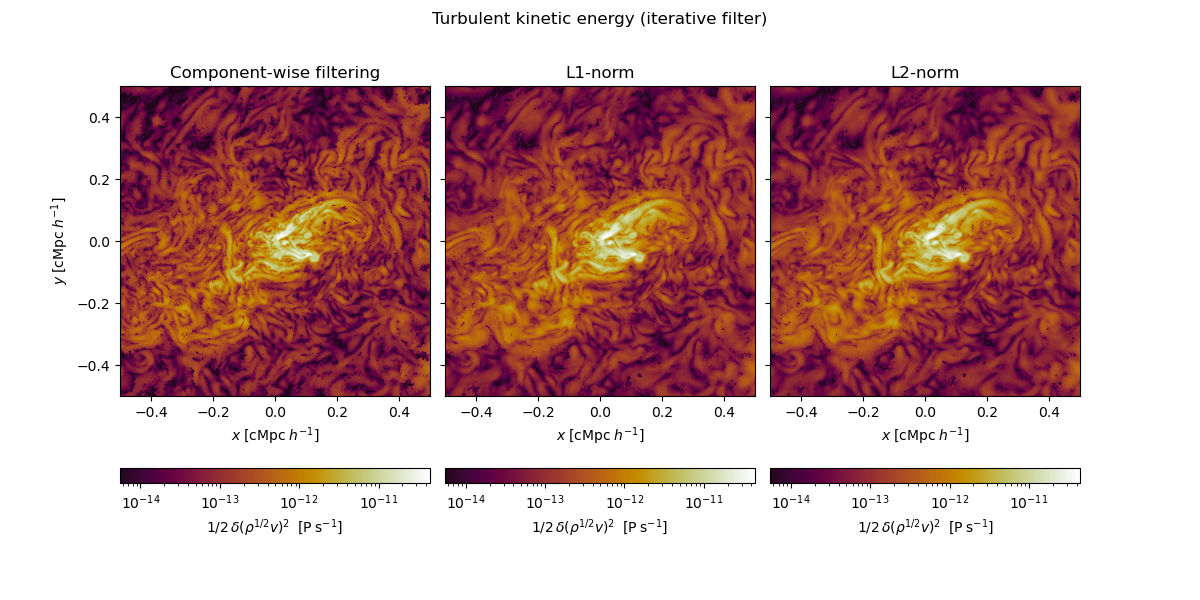

In [18]:


VEC_kin_en_turb = slicer.slice_variable(VEC_turbEner)
VEC1_kin_en_turb = slicer.slice_variable(VEC1_turbEner)
VEC2_kin_en_turb = slicer.slice_variable(VEC2_turbEner)
# kin_en_tot = kin_en_tot.to_physical.cgs
# kin_en_bulk = kin_en_bulk.to_physical.cgs
VEC_kin_en_turb = VEC_kin_en_turb.to_physical.cgs
VEC1_kin_en_turb = VEC1_kin_en_turb.to_physical.cgs
VEC2_kin_en_turb = VEC2_kin_en_turb.to_physical.cgs

vmin = 0.0001*VEC_kin_en_turb.value.max()
vmax = 0.8*VEC_kin_en_turb.value.max()
norm = LogNorm(vmin=vmin,vmax=vmax)


# vmin = 0.001*kin_en_turb.value.max()
# vmax = 0.8*kin_en_turb.value.max()
# norm1 = LogNorm(vmin=vmin,vmax=vmax)
cmap = cmr.fall

fig, axes = plt.subplots(1,3, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
    VEC_kin_en_turb.value, origin='lower', cmap=cmap, norm=norm,extent=extent.value)
im2 = axes[1].imshow(
    VEC1_kin_en_turb.value, origin='lower', cmap=cmap, norm=norm,extent=extent.value)
im3 = axes[2].imshow(
    VEC2_kin_en_turb.value, origin='lower', cmap=cmap, norm=norm,extent=extent.value)
# im3 = axes[2].imshow(
#     kin_en_turb.value, origin='lower', cmap=cmap, norm=norm,extent=extent.value)

axes[0].set_title('Component-wise filtering')
axes[1].set_title('L1-norm')
axes[2].set_title('L2-norm')
# axes[2].set_title('Turbulent')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))



cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(VEC_kin_en_turb.label('1/2 \, \\delta ( \\rho^{1/2} v)^2'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(VEC1_kin_en_turb.label('1/2 \, \\delta ( \\rho^{1/2} v)^2'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(VEC2_kin_en_turb.label('1/2 \, \\delta ( \\rho^{1/2} v)^2'))


fig.subplots_adjust(top=0.9,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Turbulent kinetic energy (iterative filter)',y=0.98)
plt.savefig('../plots/kin_energy_vector_filtering.pdf')

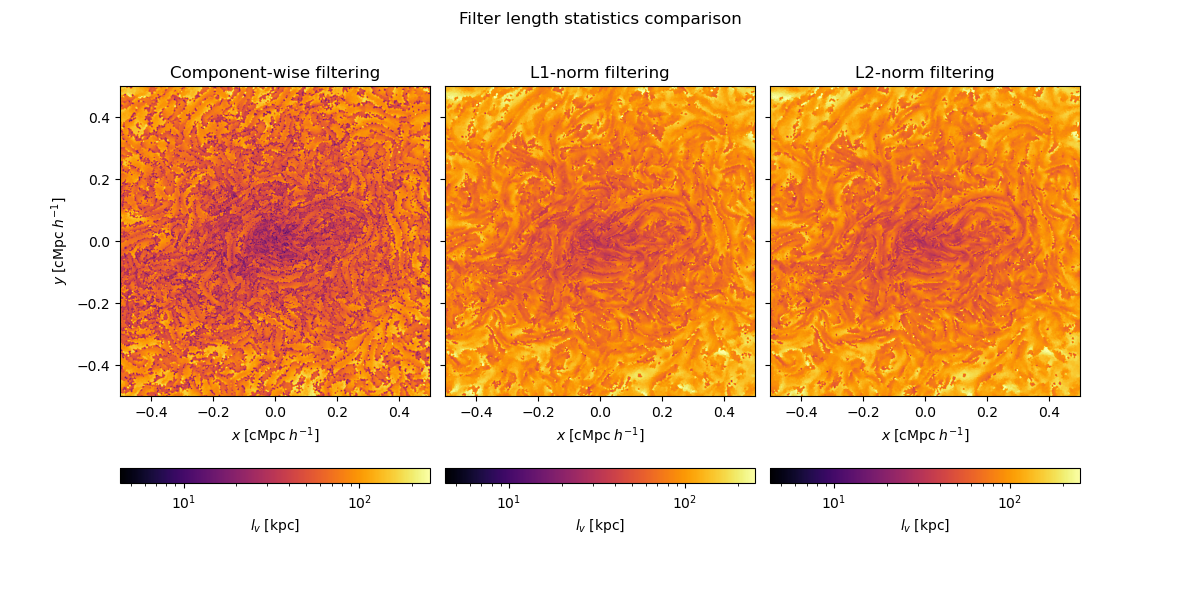

In [15]:
# slicer = pa.Slicer(snap, center, widths_slicer, 'z', npix=512)

slicer_final_filter_length_VEC = slicer.slice_variable(VEC_filter_length_vel)
slicer_final_filter_length_VEC1 = slicer.slice_variable(VEC1_filter_length_vel)
slicer_final_filter_length_VEC2 = slicer.slice_variable(VEC2_filter_length_vel)

slicer_final_filter_length_VEC = slicer_final_filter_length_VEC.to_physical.astro
slicer_final_filter_length_VEC1 = slicer_final_filter_length_VEC1.to_physical.astro
slicer_final_filter_length_VEC2 = slicer_final_filter_length_VEC2.to_physical.astro

vmin = np.min(slicer_final_filter_length_VEC.value)
vmax = np.max(slicer_final_filter_length_VEC.value)
norm = LogNorm(vmin=vmin,vmax=vmax)
extent = slicer.centered_extent.to('Mpc')
cmap=plt.cm.inferno
cmap.set_under('white')

# vmin = -0.3*np.max(np.abs(relative_delta.value))
# vmin = -1.
# vmax = -vmin
# norm1 = Normalize(vmin=vmin,vmax=vmax)
# cmap1 = plt.cm.RdBu_r
# cmap1.set_under('white')

plt.figure(1)
plt.clf()

fig, axes = plt.subplots(1,3, figsize=(12,6),sharex=True, sharey=True)

im1 = axes[0].imshow(
   slicer_final_filter_length_VEC.value, origin='lower', norm=norm,extent=extent.value, cmap=cmap)
im2 = axes[1].imshow(
    slicer_final_filter_length_VEC1.value, origin='lower', norm=norm,extent=extent.value, cmap=cmap)
im3 = axes[2].imshow(
    slicer_final_filter_length_VEC2.value, origin='lower', norm=norm,extent=extent.value, cmap=cmap)
# im3 = axes[2].imshow(
#     relative_delta.value, origin='lower', norm=norm1, extent=extent.value, cmap=cmap1)

axes[0].set_title('Component-wise filtering')
axes[1].set_title('L1-norm filtering')
axes[2].set_title('L2-norm filtering')
# axes[2].set_title('How many particles it interacted')

for i in range(3):
    axes[i].set_xlabel(extent.label('x'))

axes[0].set_ylabel(extent.label('y'))

# fig.subplots_adjust(bottom=0.2)
# cbar_ax = fig.add_axes([0.1, 0.15, 0.8, 0.05])

cbar = fig.colorbar(im1, orientation='horizontal')
cbar.set_label(slicer_final_filter_length_VEC.label(r'l_v'))

cbar = fig.colorbar(im2, orientation='horizontal')
cbar.set_label(slicer_final_filter_length_VEC.label(r'l_v'))

cbar = fig.colorbar(im3, orientation='horizontal')
cbar.set_label(slicer_final_filter_length_VEC.label(r'l_v'))
# cbar = fig.colorbar(im3, orientation='horizontal')
# cbar.set_label(relative_delta.label(r'(l_v - l_B ) / l_v'))


fig.subplots_adjust(top=0.9,
bottom=0.1,
left=0.10,
right=0.90,
hspace=0.0,
wspace=0.05)

fig.suptitle('Filter length statistics comparison',y=0.98)
plt.savefig('../plots/filter_length_comparison_vector_filtering.pdf')

In [16]:
snap['0_MagneticField'].shape

(120358394, 3)

In [17]:
snap['0_Velocities'].shape

(120358394, 3)